In [13]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [14]:
# Cell 2 — Load train and test data
train = pd.read_csv("../data/spy_train.csv", index_col=0, parse_dates=True)
test = pd.read_csv("../data/spy_test.csv", index_col=0, parse_dates=True)

features = ['Close_Lag_1', 'Close_Lag_5', 'Close_Lag_20', 
            'Daily_Return', 'Volatility_30', 'MA_20', 'MA_50']
target = 'Target'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (2172, 7) | X_test: (543, 7)


In [15]:
# Cell 3 — Baseline: Naive Forecast (next day return = 0, i.e. no change)
baseline_pred = np.zeros(len(y_test))

mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))
mape_base = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100

print("=== Baseline (Zero Return Forecast) ===")
print(f"MAE:  {mae_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")
print(f"MAPE: {mape_base:.2f}%")

=== Baseline (Zero Return Forecast) ===
MAE:  0.0066
RMSE: 0.0101
MAPE: 100.00%


In [16]:
# Cell 4 — XGBoost model
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, 
                   max_depth=4, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print("=== XGBoost ===")
print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

=== XGBoost ===
MAE:  0.0169
RMSE: 0.0194
MAPE: 1733.81%


In [17]:
# Cell 5 — Compare models
print("=== Model Comparison ===")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print(f"{'Zero Return Baseline':<25} {mae_base:>8.4f} {rmse_base:>8.4f} {mape_base:>8.2f}%")
print(f"{'XGBoost':<25} {mae_xgb:>8.4f} {rmse_xgb:>8.4f} {mape_xgb:>8.2f}%")

=== Model Comparison ===
Model                          MAE     RMSE     MAPE
Zero Return Baseline        0.0066   0.0101   100.00%
XGBoost                     0.0169   0.0194  1733.81%


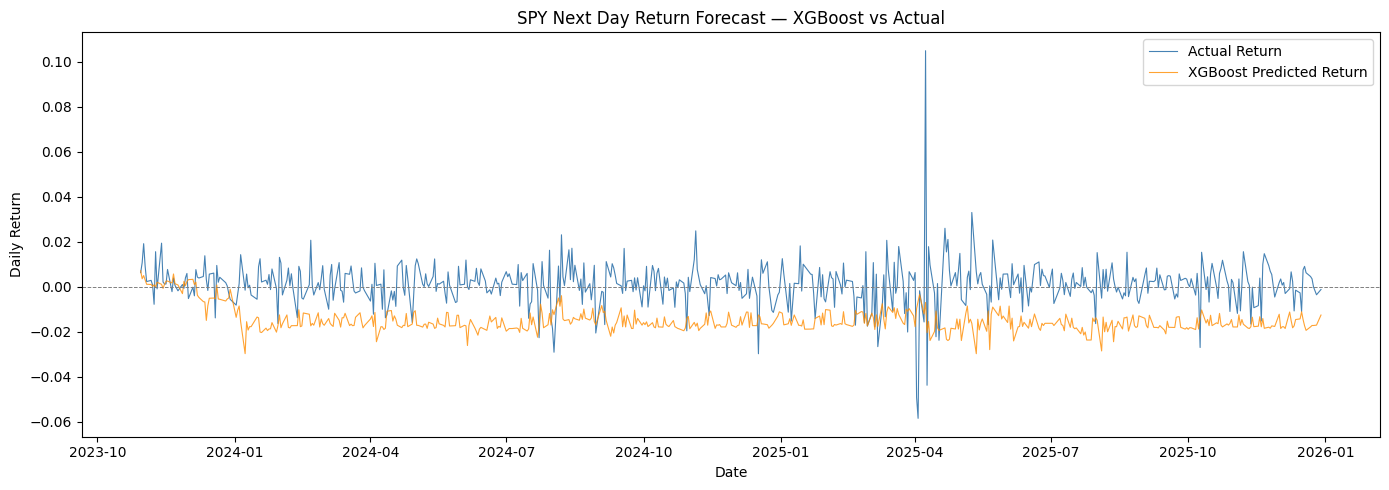

In [18]:
# Cell 6 — Visualization: predicted vs actual returns
plt.figure(figsize=(14, 5))
plt.plot(test.index, y_test, label='Actual Return', color='steelblue', linewidth=0.8)
plt.plot(test.index, xgb_pred, label='XGBoost Predicted Return', 
         color='darkorange', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.title('SPY Next Day Return Forecast — XGBoost vs Actual')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.show()